# Conditional Poisson Sampling

$$
\newcommand{\w}{{\color{#2196F3}{w}}}
\newcommand{\bw}{{\color{#2196F3}{\boldsymbol{w}}}}
\newcommand{\W}{{\color{#2196F3}{W}}}
\newcommand{\Z}{{\color{#FF9800}{Z}}}
\newcommand{\pip}{{\color{#E91E63}{\pi}}}
\newcommand{\ba}{{\color{#2196F3}{\boldsymbol{a}}}}
\newcommand{\bb}{{\color{#2196F3}{\boldsymbol{b}}}}
\newcommand{\z}{{\color{#9C27B0}{z}}}
\newcommand{\llbracket}{[\![}
\newcommand{\rrbracket}{]\!]}
$$

**Why fixed-size weighted subsets?**  Many problems require selecting exactly $n$ distinct items from a larger set, with selection probabilities controlled by item-level weights: survey sampling (draw $n$ households with probabilities proportional to size), stochastic beam search (maintain exactly $n$ hypotheses weighted by model scores), or subset selection in machine learning (choose $n$ features or data points for a diverse batch).  The hard part is doing this *exactly* — getting the right distribution, computing inclusion probabilities, and fitting weights — all efficiently.

Suppose you want to draw a random subset of exactly $n$ items from a universe $\mathcal{S}$ of $N$ items, where each item has a weight $\w_i > 0$.  The probability of drawing a particular subset $S \in \tbinom{\mathcal{S}}{n}$ is proportional to the product of its weights:

$$
P(S) = \frac{\prod_{i \in S} \w_i}{\Z\tbinom{\bw}{n}}, \quad S \in \tbinom{\mathcal{S}}{n}
$$

where $\Z\tbinom{\bw}{n} = \sum_{S \in \tbinom{\mathcal{S}}{n}} \prod_{i \in S} \w_i$ is the normalizing constant — a weighted generalization of the binomial coefficient (when $\bw = \mathbf{1}$, we recover $\Z\tbinom{\bw}{n} = \binom{N}{n}$).

This is the **conditional Poisson distribution** (also called the *exponential fixed-size design* — "exponential" because it belongs to the exponential family with natural parameters $\theta_i = \log \w_i$).  The name comes from its construction: in *Poisson sampling*, each item $i$ is included independently with probability $p_i$ — but the sample size is random.  *Conditioning* on the sample size being exactly $n$ gives the conditional Poisson distribution.  Concretely, set $p_i = \w_i/(1+\w_i)$, so the weight $\w_i$ is the *odds* of the $i$-th coin flip: $\w_i = p_i / (1 - p_i)$.

Among all distributions over size-$n$ subsets with given marginal inclusion probabilities $\pip_i = P(i \in S)$, the conditional Poisson distribution is the unique **maximum-entropy** one — it makes the fewest assumptions beyond the marginals ([Chen, Dempster & Liu, 1994](https://academic.oup.com/biomet/article-abstract/81/3/457/256956)).  This is the same sense in which the Gaussian is the max-entropy distribution with given mean and variance.

In this post, I'll describe an implementation that computes inclusion probabilities, draws exact samples, and fits weights to target probabilities — all in $O(N \log^2 N)$ time using a polynomial product tree.  The code is available as a single-file library: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling).

**As far as I can tell, this is the only publicly available library for conditional Poisson sampling in Python** (or any language outside of R's survey-sampling packages).  Existing R implementations — `UPmaxentropy` in the [sampling](https://cran.r-project.org/web/packages/sampling/) package and the [BalancedSampling](https://cran.r-project.org/web/packages/BalancedSampling/) package — use either rejection sampling or $O(Nn)$ dynamic programming.  The product-tree algorithm used here does not appear in any prior software that I'm aware of.

## Two rejection sampling constructions

There are two simple rejection sampling procedures that both produce exactly the conditional Poisson distribution.  They give useful intuition for what the distribution *is*.

**Construction 1 (Bernoulli).** For each item $i$, flip an independent coin with odds $\w_i$ (i.e., heads probability $p_i = \w_i/(1+\w_i)$).  Let $S$ be the set of heads.  Reject unless $|S| = n$.

**Construction 2 (Categorical).** Draw $n$ items i.i.d. from the categorical distribution with probabilities $\propto \w_i$ (with replacement).  Reject unless all $n$ draws are distinct.  (The acceptance probability is governed by the birthday problem: with $N$ items and $n$ draws, collisions become likely when $n \approx \sqrt{N}$, making this construction impractical for large $n/N$ ratios.)

Both yield $P(S) \propto \prod_{i \in S} \w_i$ — the extra factors ($\prod_i(1+\w_i)$ in construction 1, $n!$ and $\W^n$ in construction 2) are constant across all size-$n$ sets and cancel upon conditioning.

Note that in construction 1, the weight $\w_i$ is literally the *odds* of item $i$'s coin flip: $\w_i = p_i/(1-p_i)$.

In [1]:
def rejection_bernoulli(w, n, rng):
    """Construction 1: independent coins, condition on size = n."""
    p = w / (1 + w)
    attempts = 0
    while True:
        attempts += 1
        S = np.where(rng.random(len(w)) < p)[0]
        if len(S) == n:
            return S, attempts

def rejection_categorical(w, n, rng):
    """Construction 2: n draws with replacement, condition on all distinct."""
    p = w / w.sum()
    attempts = 0
    while True:
        attempts += 1
        draws = rng.choice(len(w), size=n, replace=True, p=p)
        if len(set(draws)) == n:
            return np.sort(draws), attempts

import numpy as np
rng_rej = np.random.default_rng(42)
N_rej, n_rej = 20, 5
w_rej = rng_rej.exponential(1.0, N_rej)

for name, sampler in [('Bernoulli',    rejection_bernoulli),
                       ('Categorical',  rejection_categorical)]:
    attempts = [sampler(w_rej, n_rej, rng_rej)[1] for _ in range(1000)]
    print(f'{name:12s}  mean attempts: {np.mean(attempts):5.1f}   max: {np.max(attempts)}')


Bernoulli     mean attempts:  19.7   max: 160
Categorical   mean attempts:   2.7   max: 16


The acceptance rates for the two constructions are:

<table>
<thead>
<tr><th>Construction</th><th>Acceptance rate</th></tr>
</thead>
<tbody>
<tr><td>Bernoulli (condition on size $n$)</td><td>$\Pr[\text{exactly } n \text{ heads}] = \sum_{|S|=n} \prod_{i \in S} p_i \prod_{i \notin S}(1 - p_i)$</td></tr>
<tr><td>Categorical (condition on all distinct)</td><td>$n! \cdot \sum_{|S|=n} \prod_{i \in S} p_i$</td></tr>
</tbody>
</table>

where $p_i = \w_i/(1+\w_i)$ is the coin-flip probability for item $i$.

The Bernoulli acceptance rate is the most natural: it's just the probability that exactly $n$ of $N$ independent coins land heads — the normalizing constant of the conditional Poisson distribution.  In terms of the odds parameterization, it equals $\Z\tbinom{\bw}{n} / \prod_i(1 + \w_i)$, but this is just a reparameterization artifact.

The categorical acceptance rate has an extra $n!$ because it draws an *ordered* tuple of $n$ items and there are $n!$ orderings of each size-$n$ set.

Both constructions produce the same conditional distribution.  The categorical version tends to be better when $n \ll N$ (collisions are rare — essentially the birthday problem), while the Bernoulli version can be better when the weights are spread out and $n/N$ is moderate.  Either way, neither construction gives you a way to compute $\Z\tbinom{\bw}{n}$, the inclusion probabilities, or gradients for fitting.  That's the gap the product tree fills.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pylab as pl
from conditional_poisson import ConditionalPoisson

## Basic usage

The simplest entry point is `from_weights`: hand it a subset size $n$ and a weight vector $\bw$.

In [3]:
N, n = 10, 4
rng = np.random.default_rng(0)
w = rng.exponential(1.0, N)

cp = ConditionalPoisson.from_weights(n, w)
print(f'N={N}, n={n}')
print(f'weights:   {np.round(w, 3)}')
print(f'pi:        {np.round(cp.pi, 3)}')
print(f'sum(pi):   {cp.pi.sum():.6f}  (should be {n})')
print(f'log Z:     {cp.log_normalizer:.4f}')

N=10, n=4
weights:   [6.800e-01 1.020e+00 2.000e-02 2.000e-03 5.500e-01 1.630e+00 6.740e-01
 7.550e-01 2.817e+00 6.058e+00]
pi:        [0.343 0.456 0.013 0.001 0.291 0.592 0.341 0.371 0.73  0.861]
sum(pi):   4.000000  (should be 4)
log Z:     5.7602


The inclusion probabilities $\pip_i = P(i \in S)$ always sum to $n$, and each $\pip_i \in (0, 1)$.  Items with larger weights get higher inclusion probabilities.

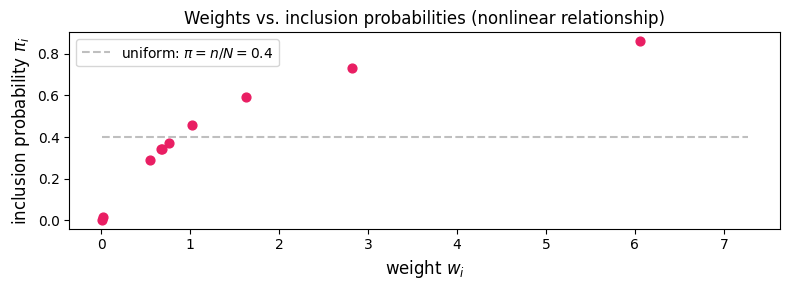

In [4]:
pl.figure(figsize=(8, 3))
pl.scatter(w, cp.pi, color='#E91E63', s=40, zorder=3)
w_grid = np.linspace(w.min() * 0.8, w.max() * 1.2, 200)
cp_grid = ConditionalPoisson.from_weights(n, w)
# Show what pi_i would be if all weights were equal to w_grid[j]
pi_uniform = n / N * np.ones_like(w_grid)  # uniform baseline
pl.plot(w_grid, pi_uniform, '--', color='gray', alpha=0.5, label=f'uniform: $\\pi = n/N = {n/N:.1f}$')
pl.xlabel('weight $w_i$', fontsize=12)
pl.ylabel('inclusion probability $\\pi_i$', fontsize=12)
pl.title('Weights vs. inclusion probabilities (nonlinear relationship)', fontsize=12)
pl.legend()
pl.tight_layout()
pl.show()

## Sampling

Drawing samples works by walking a binary tree top-down, splitting a "quota" of $n$ items between the left and right subtrees at each node.  Each split is exact (not approximate), and the tree is built once and cached, so subsequent samples are cheap.

In [5]:
M = 100_000
samples = cp.sample(M, rng=rng)
print(f'sample shape: {samples.shape}')   # (M, n)
print(f'first few samples:')
print(samples[:5])

sample shape: (100000, 4)
first few samples:
[[1 4 6 9]
 [4 7 8 9]
 [1 5 7 8]
 [0 4 8 9]
 [1 5 6 8]]


Let's verify that the empirical inclusion frequencies match the exact $\pip$ values.

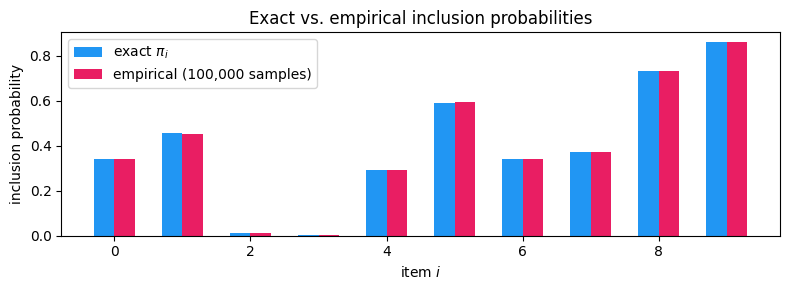

In [6]:
pi_emp = np.bincount(samples.ravel(), minlength=N) / M

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, cp.pi, width=0.3, label='exact $\pi_i$', color='#2196F3')
pl.bar(ix + 0.15, pi_emp, width=0.3, label=f'empirical ({M:,} samples)', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Exact vs. empirical inclusion probabilities')
pl.tight_layout()

## The polynomial product tree

The key idea is to encode the sum over all $\binom{N}{n}$ subsets as the coefficient of $\z^n$ in a product of polynomials:

$$
(1 + \w_1 \z)(1 + \w_2 \z) \cdots (1 + \w_N \z) = \sum_{k=0}^{N} \Z\tbinom{\bw}{k}\, \z^k
$$

The $n$-th coefficient is exactly $\Z\tbinom{\bw}{n}$, the normalizing constant.  This product can be computed in $O(N \log^2 N)$ time using a divide-and-conquer strategy on a binary tree — a standard technique from computer algebra known as the *subproduct tree* (see [von zur Gathen & Gerhard (2013)](https://doi.org/10.1017/CBO9781139856065), Chapter 10).

**Notation.** We write $\llbracket f \rrbracket(\z^k)$ for the coefficient of $\z^k$ in a formal power series $f(\z) = \sum_k a_k \z^k$, i.e., $\llbracket f \rrbracket(\z^k) = a_k$.  This is sometimes written $[\z^k]\, f(\z)$; we use the Scott bracket notation to avoid ambiguity with other uses of square brackets.

### Upward pass

Each leaf of a complete binary tree holds one degree-1 polynomial $(1 + \w_i \z)$.  Internal nodes multiply their children's polynomials.  The root holds the full product, whose $n$-th coefficient is $\Z\tbinom{\bw}{n}$.

For example, with $N = 8$ items, the tree has three levels of internal nodes.  At the first level, pairs of leaves are multiplied: $P_{12}(\z) = (1 + \w_1 \z)(1 + \w_2 \z)$, and so on.  At the next level, $P_{1234} = P_{12} \cdot P_{34}$.  The root is $P_{12345678} = P_{1234} \cdot P_{5678}$.

```mermaid
graph BT
    L1["$$(1 + w_1 z)$$"] --> N12["$$P_{12} = P_1 \cdot P_2$$"]
    L2["$$(1 + w_2 z)$$"] --> N12
    L3["$$(1 + w_3 z)$$"] --> N34["$$P_{34} = P_3 \cdot P_4$$"]
    L4["$$(1 + w_4 z)$$"] --> N34
    L5["$$(1 + w_5 z)$$"] --> N56["$$P_{56} = P_5 \cdot P_6$$"]
    L6["$$(1 + w_6 z)$$"] --> N56
    L7["$$(1 + w_7 z)$$"] --> N78["$$P_{78} = P_7 \cdot P_8$$"]
    L8["$$(1 + w_8 z)$$"] --> N78
    N12 --> N1234["$$P_{1\text{-}4} = P_{12} \cdot P_{34}$$"]
    N34 --> N1234
    N56 --> N5678["$$P_{5\text{-}8} = P_{56} \cdot P_{78}$$"]
    N78 --> N5678
    N1234 --> ROOT["$$\text{root: } P_{1\text{-}8}$$"]
    N5678 --> ROOT

    style ROOT fill:#4a90d9,color:#fff
    style N1234 fill:#4a90d9,color:#fff
    style N5678 fill:#4a90d9,color:#fff
    style N12 fill:#4a90d9,color:#fff
    style N34 fill:#4a90d9,color:#fff
    style N56 fill:#4a90d9,color:#fff
    style N78 fill:#4a90d9,color:#fff
    style L1 fill:#e0e0e0,color:#000
    style L2 fill:#e0e0e0,color:#000
    style L3 fill:#e0e0e0,color:#000
    style L4 fill:#e0e0e0,color:#000
    style L5 fill:#e0e0e0,color:#000
    style L6 fill:#e0e0e0,color:#000
    style L7 fill:#e0e0e0,color:#000
    style L8 fill:#e0e0e0,color:#000
```

**Complexity.** At each level of the tree, the total size of the polynomials being multiplied is $O(N)$, and each multiplication is done via FFT in $O(d \log d)$ time where $d$ is the degree. The recurrence is

$$T(N) = 2\,T(N/2) + O(N \log N)$$

which solves to $T(N) = O(N \log^2 N)$ by the Master Theorem.

### Downward pass (backpropagation)

The upward pass computes the product $P_{\text{root}}(\z) = \prod_i (1 + \w_i \z)$.  To get inclusion probabilities, we need the *gradient* of this product with respect to each leaf.  Since this is an exponential family with natural parameters $\theta_i = \log \w_i$, the inclusion probability is the gradient of the log-normalizer:

$$\pip_i = \frac{\partial \log \Z\tbinom{\bw}{n}}{\partial \theta_i} = \frac{\w_i \cdot \Z\tbinom{\bw^{(-i)}}{n-1}}{\Z\tbinom{\bw}{n}}$$

The numerator involves $\Z\tbinom{\bw^{(-i)}}{n-1}$, which is the $(n{-}1)$-th coefficient of the "leave-one-out" polynomial $P^{(-i)}(\z) = \prod_{j \neq i}(1 + \w_j \z)$.  So computing $\pip$ reduces to computing all $N$ leave-one-out products — which is exactly the [gradient of a product](https://timvieira.github.io/blog/gradient-of-a-product/).

The key insight is that [evaluating $\nabla f(x)$ is as fast as $f(x)$](https://timvieira.github.io/blog/evaluating-fx-is-as-fast-as-fx/): the downward pass is just **backpropagation** applied to the tree-structured product.  The upward pass is the forward pass; the downward pass propagates adjoints (outside polynomials) from root to leaves.  At each internal node, the adjoint of a child is the parent's adjoint times the *sibling's* forward value — the standard reverse-mode rule for multiplication.

Concretely: at the root, the "outside" polynomial is $1$.  When we descend to a child, its outside is the parent's outside times the sibling's inside polynomial.  The left child of the root gets outside $= P_{5678}$, the right child gets outside $= P_{1234}$.  Continuing down, leaf 1 gets outside $= P_{5678} \cdot P_2 \cdot P_{34} = P^{(-1)}$.  Each leaf ends up with the product of all *other* leaves' polynomials, without redundant work.

This is the same divide-and-conquer structure used for [heaps for incremental computation](https://timvieira.github.io/blog/heaps-for-incremental-computation/) — a balanced binary tree where each node stores an aggregate over its subtree, and updates propagate in $O(\log N)$ — but here the "values" are polynomials and the "aggregation" is polynomial multiplication.

```mermaid
graph TB
    ROOT["$$\text{outside} = 1$$"] --> N1234["$$\text{outside} = P_{5\text{-}8}$$"]
    ROOT --> N5678["$$\text{outside} = P_{1\text{-}4}$$"]
    N1234 --> N12["$$\text{outside} = P_{5\text{-}8} \cdot P_{34}$$"]
    N1234 --> N34["$$\text{outside} = P_{5\text{-}8} \cdot P_{12}$$"]
    N5678 --> N56["$$\text{outside} = P_{1\text{-}4} \cdot P_{78}$$"]
    N5678 --> N78["$$\text{outside} = P_{1\text{-}4} \cdot P_{56}$$"]
    N12 --> L1["$$P^{(-1)} = \text{out}_{12} \cdot P_2$$"]
    N12 --> L2["$$P^{(-2)} = \text{out}_{12} \cdot P_1$$"]
    N34 --> L3["$$P^{(-3)} = \text{out}_{34} \cdot P_4$$"]
    N34 --> L4["$$P^{(-4)} = \text{out}_{34} \cdot P_3$$"]
    N56 --> L5["$$P^{(-5)} = \text{out}_{56} \cdot P_6$$"]
    N56 --> L6["$$P^{(-6)} = \text{out}_{56} \cdot P_5$$"]
    N78 --> L7["$$P^{(-7)} = \text{out}_{78} \cdot P_8$$"]
    N78 --> L8["$$P^{(-8)} = \text{out}_{78} \cdot P_7$$"]

    style ROOT fill:#4a90d9,color:#fff
    style N1234 fill:#4a90d9,color:#fff
    style N5678 fill:#4a90d9,color:#fff
    style N12 fill:#4a90d9,color:#fff
    style N34 fill:#4a90d9,color:#fff
    style N56 fill:#4a90d9,color:#fff
    style N78 fill:#4a90d9,color:#fff
    style L1 fill:#e0e0e0,color:#000
    style L2 fill:#e0e0e0,color:#000
    style L3 fill:#e0e0e0,color:#000
    style L4 fill:#e0e0e0,color:#000
    style L5 fill:#e0e0e0,color:#000
    style L6 fill:#e0e0e0,color:#000
    style L7 fill:#e0e0e0,color:#000
    style L8 fill:#e0e0e0,color:#000
```

The inclusion probability is then:

$$
\pip_i = \w_i \cdot \llbracket P^{(-i)} \rrbracket(\z^{n-1}) \;/\; \Z\tbinom{\bw}{n}
$$

where $\llbracket f \rrbracket(\z^k)$ denotes the coefficient of $\z^k$ in the formal power series $f$.

### Sampling

Sampling reuses the upward-pass tree (no downward pass needed).  Starting at the root with a quota of $k = n$ items to select, we walk top-down: at each internal node, randomly split the quota between the left and right subtrees.  The probability of assigning $j$ items to the left is proportional to $\llbracket P_L \rrbracket(\z^j) \cdot \llbracket P_R \rrbracket(\z^{k-j})$ — the number of ways to choose $j$ items from the left times the number of ways to choose $k-j$ from the right, weighted by the respective products.  At the leaves, quota 1 means "include this item"; quota 0 means "exclude."

```mermaid
graph TB
    ROOT["$$\text{quota} = n$$"] -->|"$$j_1 \text{ items}$$"| LEFT["$$\text{quota} = j_1$$"]
    ROOT -->|"$$n - j_1 \text{ items}$$"| RIGHT["$$\text{quota} = n - j_1$$"]
    LEFT -->|"$$j_2$$"| LL["$$\text{quota} = j_2$$"]
    LEFT -->|"$$j_1 - j_2$$"| LR["$$\text{quota} = j_1 - j_2$$"]
    RIGHT -->|"$$j_3$$"| RL["$$\text{quota} = j_3$$"]
    RIGHT -->|"$$n - j_1 - j_3$$"| RR["$$\text{quota} = n - j_1 - j_3$$"]
    LL --> L1["$$0 \text{ or } 1$$"]
    LL --> L2["$$0 \text{ or } 1$$"]
    LR --> L3["$$0 \text{ or } 1$$"]
    LR --> L4["$$0 \text{ or } 1$$"]
    RL --> L5["$$0 \text{ or } 1$$"]
    RL --> L6["$$0 \text{ or } 1$$"]
    RR --> L7["$$0 \text{ or } 1$$"]
    RR --> L8["$$0 \text{ or } 1$$"]

    style ROOT fill:#4a90d9,color:#fff
    style LEFT fill:#4a90d9,color:#fff
    style RIGHT fill:#4a90d9,color:#fff
    style LL fill:#4a90d9,color:#fff
    style LR fill:#4a90d9,color:#fff
    style RL fill:#4a90d9,color:#fff
    style RR fill:#4a90d9,color:#fff
    style L1 fill:#e0e0e0,color:#000
    style L2 fill:#e0e0e0,color:#000
    style L3 fill:#e0e0e0,color:#000
    style L4 fill:#e0e0e0,color:#000
    style L5 fill:#e0e0e0,color:#000
    style L6 fill:#e0e0e0,color:#000
    style L7 fill:#e0e0e0,color:#000
    style L8 fill:#e0e0e0,color:#000
```

In pseudocode:

```python
def sample(node, quota):
    if node.is_leaf:
        return [node.item] if quota == 1 else []
    # P_L[j] * P_R[quota-j] for j = 0, ..., quota
    probs = [node.left.poly[j] * node.right.poly[quota - j]
             for j in range(quota + 1)]
    j = categorical(probs)              # how many items from the left subtree
    return sample(node.left, j) + sample(node.right, quota - j)

S = sample(root, n)                     # exactly n items
```

The tree is built once ($O(N \log^2 N)$) and reused for each sample ($O(n \log N)$ per sample) — at each of the $O(\log N)$ levels, only nodes whose quota is nonzero are visited, and there are at most $n$ such nodes.  (When $n \approx N$, nearly all nodes are visited, so the per-sample cost approaches $O(N \log N)$.)  No $\binom{N}{n}$-sized table is ever constructed.

In [7]:
# Worked example: N=4, n=2 — trace the upward and downward passes
from scipy.signal import convolve as poly_mul

w_ex = np.array([2.0, 3.0, 1.0, 5.0])
n_ex = 2

# ── Upward pass ──
P = {}
for i in range(4):
    P[i] = np.array([1.0, w_ex[i]])

P['L']  = poly_mul(P[0], P[1])       # (1+2z)(1+3z)
P['R']  = poly_mul(P[2], P[3])       # (1+z)(1+5z)
P['root'] = poly_mul(P['L'], P['R']) # full product

print("=== Upward pass (inside polynomials) ===")
print(f"  P₁(z) = {P[0]}  →  (1 + {w_ex[0]}z)")
print(f"  P₂(z) = {P[1]}  →  (1 + {w_ex[1]}z)")
print(f"  P₃(z) = {P[2]}  →  (1 + {w_ex[2]}z)")
print(f"  P₄(z) = {P[3]}  →  (1 + {w_ex[3]}z)")
print(f"  P_L(z)    = {P['L']}  →  1 + {P['L'][1]}z + {P['L'][2]}z²")
print(f"  P_R(z)    = {P['R']}  →  1 + {P['R'][1]}z + {P['R'][2]}z²")
print(f"  P_root(z) = {P['root']}")
print(f"\n  Z(w,2) = coeff of z² = {P['root'][n_ex]}")
print(f"  (check: 2·3 + 2·1 + 2·5 + 3·1 + 3·5 + 1·5 = {sum(w_ex[i]*w_ex[j] for i in range(4) for j in range(i+1,4))})")

# ── Downward pass ──
oP = {}
oP['root'] = np.array([1.0])         # outside of root = 1
oP['L']  = P['R']                    # outside of left  = sibling (right inside)
oP['R']  = P['L']                    # outside of right = sibling (left inside)
oP[0] = poly_mul(oP['L'], P[1])      # outside of leaf 0 = out_L · P₂
oP[1] = poly_mul(oP['L'], P[0])      # outside of leaf 1 = out_L · P₁
oP[2] = poly_mul(oP['R'], P[3])      # outside of leaf 2 = out_R · P₄
oP[3] = poly_mul(oP['R'], P[2])      # outside of leaf 3 = out_R · P₃

print("\n=== Downward pass (outside / leave-one-out polynomials) ===")
print(f"  out_root = {oP['root']}")
print(f"  out_L    = P_R = {oP['L']}")
print(f"  out_R    = P_L = {oP['R']}")
for i in range(4):
    print(f"  P⁽⁻{i+1}⁾(z) = {oP[i]}  →  coeff of z¹ = {oP[i][n_ex-1]}")

# ── Inclusion probabilities ──
Z = P['root'][n_ex]
pi_ex = np.array([w_ex[i] * oP[i][n_ex - 1] / Z for i in range(4)])
print(f"\n=== Inclusion probabilities (n={n_ex}) ===")
for i in range(4):
    print(f"  π_{i+1} = w_{i+1} · [z^{n_ex-1}] P⁽⁻{i+1}⁾ / Z = {w_ex[i]} · {oP[i][n_ex-1]} / {Z} = {pi_ex[i]:.4f}")
print(f"  sum(π) = {pi_ex.sum():.4f}  (should be {n_ex})")

# Verify against ConditionalPoisson
cp_ex = ConditionalPoisson.from_weights(n_ex, w_ex)
print(f"\n  ConditionalPoisson π = {cp_ex.pi.round(4)}  ✓" if np.allclose(pi_ex, cp_ex.pi) else "  MISMATCH!")

=== Upward pass (inside polynomials) ===
  P₁(z) = [1. 2.]  →  (1 + 2.0z)
  P₂(z) = [1. 3.]  →  (1 + 3.0z)
  P₃(z) = [1. 1.]  →  (1 + 1.0z)
  P₄(z) = [1. 5.]  →  (1 + 5.0z)
  P_L(z)    = [1. 5. 6.]  →  1 + 5.0z + 6.0z²
  P_R(z)    = [1. 6. 5.]  →  1 + 6.0z + 5.0z²
  P_root(z) = [ 1. 11. 41. 61. 30.]

  Z(w,2) = coeff of z² = 41.0
  (check: 2·3 + 2·1 + 2·5 + 3·1 + 3·5 + 1·5 = 41.0)

=== Downward pass (outside / leave-one-out polynomials) ===
  out_root = [1.]
  out_L    = P_R = [1. 6. 5.]
  out_R    = P_L = [1. 5. 6.]
  P⁽⁻1⁾(z) = [ 1.  9. 23. 15.]  →  coeff of z¹ = 9.0
  P⁽⁻2⁾(z) = [ 1.  8. 17. 10.]  →  coeff of z¹ = 8.0
  P⁽⁻3⁾(z) = [ 1. 10. 31. 30.]  →  coeff of z¹ = 10.0
  P⁽⁻4⁾(z) = [ 1.  6. 11.  6.]  →  coeff of z¹ = 6.0

=== Inclusion probabilities (n=2) ===
  π_1 = w_1 · [z^1] P⁽⁻1⁾ / Z = 2.0 · 9.0 / 41.0 = 0.4390
  π_2 = w_2 · [z^1] P⁽⁻2⁾ / Z = 3.0 · 8.0 / 41.0 = 0.5854
  π_3 = w_3 · [z^1] P⁽⁻3⁾ / Z = 1.0 · 10.0 / 41.0 = 0.2439
  π_4 = w_4 · [z^1] P⁽⁻4⁾ / Z = 5.0 · 6.0 / 41.0 =

<details>
<summary><b>Brute-force verification</b> (click to expand)</summary>

For small instances, we can enumerate all $\binom{N}{n}$ subsets and verify that the efficient algorithm gets the right answer.  (See also the test suite in `test_conditional_poisson.py`.)

</details>

In [8]:
from itertools import combinations

N_small, n_small = 7, 3
w_small = rng.exponential(1.0, N_small)
cp_small = ConditionalPoisson.from_weights(n_small, w_small)

# Brute force: enumerate all subsets
all_S = list(combinations(range(N_small), n_small))
log_unnorm = np.array([np.log(np.prod(w_small[list(s)])) for s in all_S])
log_Z_bf = np.log(np.exp(log_unnorm).sum())   # log Z from brute force
log_probs_bf = log_unnorm - log_Z_bf           # normalise

# Inclusion probabilities from brute force
probs_bf = np.exp(log_probs_bf)
pi_bf = np.zeros(N_small)
for k, s in enumerate(all_S):
    for i in s:
        pi_bf[i] += probs_bf[k]

print(f'max |pi_tree - pi_brute_force| = {np.max(np.abs(cp_small.pi - pi_bf)):.2e}')
print(f'sum P(S) via brute force       = {probs_bf.sum():.10f}')
print(f'log Z: tree={cp_small.log_normalizer:.6f}, brute force={log_Z_bf:.6f}')

max |pi_tree - pi_brute_force| = 2.22e-16
sum P(S) via brute force       = 1.0000000000
log Z: tree=2.882672, brute force=2.882672


## Fitting weights to target probabilities

A common use case: you know the inclusion probabilities you *want* (e.g., from a survey design or an optimal allocation), and you need to find weights that produce them.

This is a convex optimization problem.  Since $\log P(S) = \sum_{i \in S} \theta_i - \log \Z\tbinom{\bw}{n}$, we maximise the expected log-probability under the target marginals:

$$
L(\theta) = \pip^{*\top} \theta - \log \Z\tbinom{\bw}{n}
$$

This is convex because $\log \Z$ is a log-partition function (the distribution is an exponential family with sufficient statistics $\mathbf{1}[i \in S]$).  The gradient is $\pip^* - \pip(\theta)$ and the Hessian is $-\text{Cov}[\mathbf{1}_S]$, the negative covariance matrix of the inclusion indicators.  We use Newton-CG — the Hessian-vector product $\text{Cov}[\mathbf{1}_S]\, v$ is computed via the **D-tree**, a second product tree that differentiates the P-tree polynomial with respect to the weights in direction $v$.  Where the P-tree computes $P_T(\z) = \prod_{i \in T}(1 + \w_i \z)$, the D-tree computes its directional derivative $D_T(\z) = \sum_{i \in T} v_i \w_i \prod_{j \in T, j \neq i}(1 + \w_j \z)$ using the product rule at each internal node: $D[\text{node}] = D[L] \cdot P[R] + P[L] \cdot D[R]$.  A joint downward pass then delivers both $P^{(-i)}$ and $D^{(-i)}$ at every leaf, giving the full Hessian-vector product in $O(N \log^2 N)$.

In [9]:
# Target: the inclusion probabilities from our earlier example
pi_star = cp.pi.copy()

# Fit from scratch
cp_fit = ConditionalPoisson.fit(pi_star, n, verbose=True)

  iter   0:  max|pi*-pi| = 3.332e-02
  iter   1:  max|pi*-pi| = 2.606e-03
  iter   2:  max|pi*-pi| = 2.036e-05
  iter   3:  max|pi*-pi| = 1.994e-09
  iter   4:  max|pi*-pi| = 7.661e-15


max |pi_fit - pi_target| = 8.27e-15


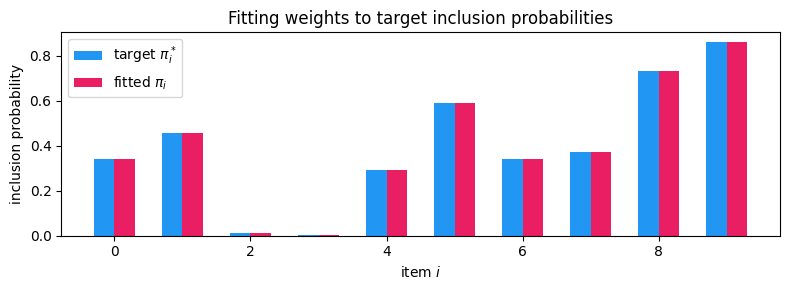

In [10]:
print(f'max |pi_fit - pi_target| = {np.max(np.abs(cp_fit.pi - pi_star)):.2e}')

pl.figure(figsize=(8, 3))
ix = np.arange(N)
pl.bar(ix - 0.15, pi_star, width=0.3, label='target $\pi^*_i$', color='#2196F3')
pl.bar(ix + 0.15, cp_fit.pi, width=0.3, label='fitted $\pi_i$', color='#E91E63')
pl.xlabel('item $i$')
pl.ylabel('inclusion probability')
pl.legend()
pl.title('Fitting weights to target inclusion probabilities')
pl.tight_layout()

## Numerical stability

Every polynomial in the tree is stored in a scaled representation `(coeffs, log_scale)` with $\max|c_k| = 1$, so FFT convolutions always operate on $O(1)$-magnitude numbers — let's verify with some stress tests.

In [11]:
cases = [
    ('large positive theta',  ConditionalPoisson(4, rng.uniform(30, 50, 10))),
    ('large negative theta',  ConditionalPoisson(4, rng.uniform(-50, -30, 10))),
    ('wide range theta',      ConditionalPoisson(4, np.linspace(-30, 30, 10))),
    ('N=100, n=50, uniform',  ConditionalPoisson(50, np.full(100, 2.0))),
    ('N=200, n=100, uniform', ConditionalPoisson(100, np.full(200, 10.0))),
    ('N=500, n=250, uniform', ConditionalPoisson(250, np.full(500, 5.0))),
]

print(f'{"case":30s}  {"sum(pi)":>10s}  {"log Z":>12s}  {"ok":>4s}')
print('-' * 62)
for name, cpt in cases:
    pi_t = cpt.pi
    ok = (np.isfinite(pi_t).all() and np.isfinite(cpt.log_normalizer)
          and abs(pi_t.sum() - cpt.n) < 1e-4)
    print(f'{name:30s}  {pi_t.sum():10.4f}  {cpt.log_normalizer:12.2f}  {"✓" if ok else "✗":>4s}')

case                               sum(pi)         log Z    ok
--------------------------------------------------------------
large positive theta                4.0000        185.40     ✓
large negative theta                4.0000       -138.80     ✓
wide range theta                    4.0000         80.00     ✓
N=100, n=50, uniform               50.0000        166.78     ✓
N=200, n=100, uniform             100.0000       1135.75     ✓
N=500, n=250, uniform             250.0000       1593.24     ✓


## Timing

The tree-based approach scales to moderately large $N$ comfortably.  For comparison, the naive $O(Nn)$ DP baseline is also shown.

In [12]:
import time

def dp_pi(w, n):
    """O(Nn) DP for inclusion probabilities (baseline)."""
    N = len(w)
    # Forward: e[m][k] = Z(w[:m], k)
    e = np.zeros((N + 1, n + 1))
    e[0, 0] = 1.0
    for m in range(N):
        e[m + 1, 0] = e[m, 0]
        for k in range(1, n + 1):
            e[m + 1, k] = e[m, k] + w[m] * e[m, k - 1]
    Z = e[N, n]
    # Backward: leave-one-out
    pi = np.empty(N)
    for i in range(N):
        # Z^{(-i)}(n-1) via inclusion-exclusion from e
        # Simpler: use the formula pi_i = w_i * Z^{(-i)}_{n-1} / Z
        # Compute Z^{(-i)} by removing item i from the DP
        ei = np.zeros(n)
        ei[0] = 1.0
        for m in range(N):
            if m == i:
                continue
            for k in range(min(n - 1, m + 1), 0, -1):
                ei[k] += w[m] * ei[k - 1]
        pi[i] = w[i] * ei[n - 1] / Z
    return pi

print(f'{"N":>6s}  {"n":>6s}  {"tree pi (ms)":>14s}  {"DP pi (ms)":>12s}  {"speedup":>8s}  {"10k samples (ms)":>18s}')
print('-' * 80)
for N_t, n_t in [(50, 20), (100, 40), (200, 80), (500, 200)]:
    w_t = rng.exponential(1.0, N_t)
    cp_t = ConditionalPoisson.from_weights(n_t, w_t)

    reps = max(1, int(800 / (N_t * n_t**0.5)))

    t0 = time.perf_counter()
    for _ in range(reps): cp_t._cache.clear(); cp_t.pi
    pi_ms = (time.perf_counter() - t0) / reps * 1000

    dp_reps = max(1, reps // 2) if N_t <= 200 else 1
    t0 = time.perf_counter()
    for _ in range(dp_reps): dp_pi(w_t, n_t)
    dp_ms = (time.perf_counter() - t0) / dp_reps * 1000

    t0 = time.perf_counter()
    cp_t.sample(10_000, rng=rng)
    samp_ms = (time.perf_counter() - t0) * 1000

    print(f'{N_t:>6d}  {n_t:>6d}  {pi_ms:>14.1f}  {dp_ms:>12.1f}  {dp_ms/pi_ms:>7.1f}x  {samp_ms:>18.0f}')

     N       n    tree pi (ms)    DP pi (ms)   speedup    10k samples (ms)
--------------------------------------------------------------------------------
    50      20             5.2          15.1      2.9x                  27
   100      40             9.2         116.0     12.6x                  56
   200      80            26.9        1031.8     38.4x                 121
   500     200            44.1       17326.6    393.1x                 371


## Application: Horvitz-Thompson estimation

A key application of CPS is unbiased estimation via the **Horvitz-Thompson estimator** ([Horvitz & Thompson, 1952](https://doi.org/10.1080/01621459.1952.10483446)).  Given a distribution $p$ over a universe $\mathcal{S}$, we want to estimate $\mu = \sum_i p(i)\, f(i)$ without evaluating $f$ on every element.

Drawing $n$ distinct elements $S \sim P_n$ and applying the Horvitz-Thompson estimator:

$$
\hat{\mu}_{\text{HT}}(S) = \sum_{i \in S} \frac{p(i)}{\pip_i}\, f(i), \quad S \sim P_n
$$

gives an unbiased estimate: $\mathbb{E}[\hat{\mu}_{\text{HT}}] = \mu$, provided $\pip_i > 0$ whenever $p(i) > 0$.

The advantage over Monte Carlo (i.i.d. sampling): MC wastes evaluations resampling high-probability elements, while SWOR guarantees $n$ *distinct* evaluations.  CPS makes this practical because we can efficiently compute both the samples and the inclusion probabilities $\pip_i$ that the estimator needs.

For more on SWOR-based estimation (including the near-optimal priority sampling scheme), see my earlier post on [estimating means in a finite universe](https://timvieira.github.io/blog/post/2017/07/03/estimating-means-in-a-finite-universe/).

## Identities for $\Z$ and its relatives

The normalizing constant $\Z\tbinom{\bw}{n}$ is the $n$-th elementary symmetric polynomial $e_n(\bw)$.  Here are some useful identities.

### Parameterizations

The conditional Poisson distribution arises from Poisson sampling — flip $N$ independent coins with $\Pr[\text{heads}_i] = p_i$, condition on exactly $n$ heads.  There are two natural parameterizations:

| | Probability $p_i$ | Odds $\w_i$ |
|---|---|---|
| **Parameter** | $p_i \in (0,1)$ | $\w_i = p_i/(1-p_i) \in (0,\infty)$ |
| **Leaf polynomial** | $(1-p_i) + p_i\, \z$ | $1 + \w_i\, \z$ |
| **Generating function** | $\prod_i\big((1-p_i) + p_i \z\big) = \sum_k \Pr[k \text{ heads}]\, \z^k$ | $\prod_i(1 + \w_i \z) = \sum_k \Z\tbinom{\bw}{k} \z^k$ |
| **$k$-th coefficient** | $\Pr[\text{exactly } k \text{ heads}]$ | $\Z\tbinom{\bw}{k}$ |

The two generating functions are related by factoring out $\prod_i(1-p_i) = 1/\prod_i(1+\w_i)$:

$$\prod_i\big((1-p_i) + p_i \z\big) = \prod_i(1-p_i) \cdot \prod_i(1 + \w_i \z)$$

so $\Pr[k \text{ heads}] = \Z\tbinom{\bw}{k} / \prod_i(1+\w_i)$.

The odds parameterization is more convenient for computation (the leaf polynomial $1 + \w_i \z$ is monic), while the probability parameterization is more natural for interpretation (the normalizer is literally $\Pr[n \text{ heads}]$).  The conditional distribution is the same either way — scaling all weights by $\alpha > 0$ doesn't change it.

### Differential identities

As discussed in the [downward pass section](#Downward-pass-(backpropagation)), the inclusion probability is the gradient of the log-normalizer (since CPS is an exponential family):

$$\pip_i = \frac{\partial \log \Z}{\partial \theta_i} = \frac{\w_i \cdot \Z\tbinom{\bw^{(-i)}}{n-1}}{\Z\tbinom{\bw}{n}}$$

The second derivative gives the covariance matrix of the inclusion indicators:

$$\text{Cov}[\mathbf{1}_{i \in S},\, \mathbf{1}_{j \in S}] = \frac{\partial^2 \log \Z}{\partial \theta_i \partial \theta_j}$$

This Hessian is what the D-tree computes (via a second backpropagation) for Newton-CG fitting.

The leave-one-out formula generalizes to **higher-order inclusion probabilities**: $\pip(X) = P(X \subseteq S) = \prod_{i \in X} \w_i \cdot \Z\tbinom{\bw^{(-X)}}{n-|X|} / \Z\tbinom{\bw}{n}$.

### Recurrences and algorithms

**Weighted Pascal recurrence.** The $O(Nn)$ dynamic programming algorithm for $\Z$:

$$\Z\tbinom{\w_1, \ldots, \w_m}{k} = \Z\tbinom{\w_1, \ldots, \w_{m-1}}{k} + \w_m \cdot \Z\tbinom{\w_1, \ldots, \w_{m-1}}{k-1}$$

This is a weighted generalization of Pascal's identity $\binom{m}{k} = \binom{m-1}{k} + \binom{m-1}{k-1}$.  Include item $m$ (second term) or exclude it (first term).

**Vandermonde's identity (weighted).** For disjoint groups $A, B$:

$$\Z\tbinom{(\ba, \bb)}{k} = \sum_{j=0}^{k} \Z\tbinom{\ba}{j} \cdot \Z\tbinom{\bb}{k-j}$$

This is why polynomial multiplication computes $\Z$: the coefficients of $P_A(\z) \cdot P_B(\z)$ are exactly the convolution of the two groups' elementary symmetric polynomials.  It is the identity that makes the product tree correct, and it is the set-level Vandermonde identity $\binom{A \cup B}{k} = \bigcup_{j=0}^{k} \binom{A}{j} \uplus \binom{B}{k-j}$.

**Newton's identities.** The elementary symmetric polynomials can be computed from **power sums** $g_k = \sum_i \w_i^k$ (see [Stanley (1999)](https://doi.org/10.1017/CBO9780511609589), Chapter 7):

$$\Z\tbinom{\bw}{k} = \sum_{i=1}^{k} \frac{(-1)^{i-1}}{k}\, \Z\tbinom{\bw}{k-i} \cdot g_i$$

This is an $O(Nn)$ algorithm that only needs the power sums, not the individual weights — useful when the universe is implicitly defined (e.g., paths in a weighted finite-state automaton, where $g_k$ can be computed via matrix methods).

### Connection to K-DPPs

A $K$-DPP (fixed-size determinantal point process) on $\{1, \ldots, N\}$ with a **diagonal** kernel matrix $L = \text{diag}(\w_1, \ldots, \w_N)$ is exactly the conditional Poisson distribution:

$$\mathcal{P}_L^K(S) = \frac{\det(L_S)}{\sum_{|S'|=K} \det(L_{S'})} = \frac{\prod_{i \in S} \w_i}{\Z\tbinom{\bw}{K}}$$

since the determinant of a diagonal submatrix is the product of its diagonal entries.  The normalizer $\sum_{|S|=K} \det(L_S) = e_K(\lambda_1, \ldots, \lambda_N)$ is an elementary symmetric polynomial of the eigenvalues — which for a diagonal matrix are just the weights.  Newton's identities connect the two: compute $e_K$ from the power sums $g_k = \text{tr}(L^k)$.

For non-diagonal $L$, the K-DPP introduces correlations between items (repulsion), while CPS has only the size constraint.  See [Kulesza & Taskar (2011)](https://arxiv.org/abs/1207.6083) for details.

## Summary

The conditional Poisson distribution is the natural maximum-entropy distribution over fixed-size subsets.  The polynomial product tree gives us an efficient way to compute everything we need:

 * **Upward pass**: builds the product polynomial $\prod_i (1 + \w_i \z)$ in a binary tree.  The root's $n$-th coefficient is the normalizing constant $\Z\tbinom{\bw}{n}$.

 * **Downward pass**: propagates leave-one-out polynomials to every leaf, giving inclusion probabilities $\pip_i$ in a single $O(N \log^2 N)$ sweep.

 * **Sampling**: walks the tree top-down, splitting a quota at each node.  Each sample costs $O(n \log N)$.  The tree is built once and reused.

 * **Hessian-vector products**: the D-tree applies the product rule to differentiate the P-tree polynomial in a direction $v$, computing $\text{Cov}[\mathbf{1}_S]\, v$ in $O(N \log^2 N)$ for Newton-CG fitting to target inclusion probabilities.

The tree build cost follows the divide-and-conquer recurrence $T(N) = 2\,T(N/2) + O(N \log N)$, giving $T(N) = O(N \log^2 N)$.  All polynomials use a scaled representation that prevents floating-point overflow even for extreme weights.

Code: [`conditional_poisson.py`](https://github.com/timvieira/conditional-poisson-sampling)

**References:**

- [Hájek (1964)](https://doi.org/10.1214/aoms/1177700375). "Asymptotic Theory of Rejective Sampling with Varying Probabilities from a Finite Population." *The Annals of Mathematical Statistics*, 35(4), 1491–1523.

- [Chen, Dempster & Liu (1994)](https://academic.oup.com/biomet/article-abstract/81/3/457/256956). "Weighted Finite Population Sampling to Maximize Entropy." *Biometrika*, 81(3), 457–469.

- [Horvitz & Thompson (1952)](https://doi.org/10.1080/01621459.1952.10483446). "A Generalization of Sampling Without Replacement from a Finite Universe." *Journal of the American Statistical Association*, 47(260), 663–685.

- [Stanley (1999)](https://doi.org/10.1017/CBO9780511609589). *Enumerative Combinatorics*, Volume 2. Cambridge University Press.

- [von zur Gathen & Gerhard (2013)](https://doi.org/10.1017/CBO9781139856065). *Modern Computer Algebra*, 3rd edition. Cambridge University Press.

- [Tillé (2006)](https://link.springer.com/book/10.1007/978-0-387-34240-0). *Sampling Algorithms*. Springer.

- [Meister, Amini, Vieira & Cotterell (2021)](https://aclanthology.org/2021.emnlp-main.52/). "Conditional Poisson Stochastic Beams." *Proceedings of EMNLP 2021*.